# Project: Mental Health Treatment-Seeking Prediction
### Michael Steven Lamprea Vera & Jeyson Carmona Bedoya

**Dataset:** OSMI Mental Health in Tech Survey  
**Objective:** Predict whether a person seeks mental health treatment (`treatment` → `Target`), using workplace, demographic, and attitudinal survey data from tech employees.

**Why this matters:** mental health in the tech industry is often under-discussed, and many employees who could benefit from treatment never seek it. Understanding which factors (family history, workplace support, awareness of available resources, etc.) are associated with treatment-seeking can help companies design better mental health policies and identify where stigma or lack of awareness is holding people back.

## 🗺️ Notebook Roadmap

This notebook follows a standard end-to-end ML classification pipeline, step by step:

| Section | Phase | What happens |
|---|---|---|
| 1–2 | Setup | Install and import the libraries used throughout the project |
| 3 | Load data | Download the OSMI survey dataset directly from Kaggle |
| 4 | Clean data | Standardize messy free-text fields (mainly `gender`) and filter invalid ages |
| 5 | EDA | Explore distributions, nulls, and the shape of the target variable |
| 6 | Encode | Turn categorical text columns into numbers so models can use them |
| 7 | Visualize | Correlation matrix, pairplots, and box plots to understand relationships |
| 8–9 | Split | Discuss feature-selection methods conceptually, then split into train/test |
| 10 | Define models | Set up 9 different classifiers and the evaluation helper functions |
| 11 | Tune | Hyperparameter search (`GridSearchCV`) for every model |
| 12 | Evaluate (no PCA) | Test-set performance of every tuned model |
| 13–14 | PCA | Apply PCA and re-evaluate every model on the reduced feature space |
| 15 | Compare | Does PCA help or hurt? Compare both pipelines side by side, and explain why |
| 16 | Pick winner | Select the single best-performing model overall |
| 17 | Explain | Which features actually drive the prediction? |
| 18 | ROC curve | How well does the final model separate the two classes? |
| 📌 | Conclusions | Final summary, limitations, and ideas for future work |

**Pipeline summary:** Load → Cleaning → EDA → Encoding → Modeling → Evaluation (with & without PCA) → Final model selection.

## 1. Installing Dependencies

We install the libraries this project depends on. Most of them (`pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn`) are used for data handling, modeling, and visualization. `kagglehub` lets us pull the dataset directly from Kaggle without manually downloading a CSV. `category_encoders`, `skrebate`, and `boruta` are installed for potential advanced feature-selection experiments (mentioned conceptually in Section 8) but are not strictly required by the core pipeline below.

In [1]:
# -q keeps pip's output quiet; safe to re-run this cell multiple times (e.g. after a kernel restart)
!pip install -q category_encoders skrebate boruta matplotlib seaborn scikit-learn pandas numpy kagglehub


  Preparing metadata (setup.py) ... done


## 2. Importing Required Libraries

Libraries are grouped by purpose:
- **Data handling:** `os`, `numpy`, `pandas`
- **Visualization:** `seaborn`, `matplotlib`
- **Preprocessing:** `StandardScaler`, `MinMaxScaler`, `LabelEncoder`, `PCA`
- **Model selection:** `train_test_split`, `StratifiedKFold`, `GridSearchCV`
- **Feature selection:** `SelectKBest`, `chi2`, `RFE`, `mutual_info_classif` (referenced conceptually in Section 8)
- **Classifiers:** 9 algorithms covering tree-based, linear, distance-based, margin-based, and neural-network approaches (details in Section 10)
- **Metrics:** accuracy, precision, recall, F1, confusion matrix, classification report, and ROC/AUC

`warnings` are suppressed to keep the notebook output clean, since some models throw harmless convergence warnings during hyperparameter search.

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Preprocessing & dimensionality reduction ---
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# --- Train/test splitting & hyperparameter search ---
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV

# --- Feature selection utilities (conceptual reference, see Section 8) ---
from sklearn.feature_selection import SelectKBest, chi2, RFE, mutual_info_classif

# --- Classifiers: linear models ---
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV, SGDClassifier

# --- Classifiers: tree-based models ---
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier

# --- Classifiers: distance-based, neural network, and margin-based models ---
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

# --- Evaluation metrics ---
from sklearn.metrics import make_scorer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

warnings.filterwarnings('ignore')  # hides harmless convergence/deprecation warnings during GridSearchCV
sns.set_theme(style='ticks')


## 3. Loading the Dataset

**What we do here:** the dataset is downloaded directly from Kaggle using `kagglehub`, so no manual file upload is needed — this cell works as-is both locally and on Kaggle, and the download is cached after the first run.

**Dataset:** mental-health-in-tech-survey, obtained from Kaggle: https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey

This is the 2014 OSMI (Open Sourcing Mental Illness) survey of tech industry employees, covering demographics, company mental-health policies, and personal attitudes toward seeking help.

In [3]:
import kagglehub

# Download the dataset (cached locally after the first run) and locate the CSV file inside it
dataset_path = kagglehub.dataset_download('osmi/mental-health-in-tech-survey')
csv_path = os.path.join(dataset_path, 'survey.csv')

data = pd.read_csv(csv_path)
print(f'Dimensions: {data.shape}')
print(f'Columns: {list(data.columns)}')
data.head()  # quick visual check that the data loaded correctly


Dimensions: (1259, 27)
Columns: ['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence', 'comments']


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


## 4. Data Cleaning

**What we do here:** the raw survey allowed free-text entry in several fields, which means the same answer can show up written in many different ways (e.g. gender, or an age typed as `999` or `-1`). Before any analysis, we need to standardize these fields so the data is consistent and usable.

- **Columns:** normalized to lowercase with no spaces, so column names are predictable and easy to reference in code.
- **Gender:** the raw column has dozens of distinct free-text values (e.g. `m`, `Male-ish`, `Cis Male`, `woman`, `uwu`, `im shay`, `im gay`) which are consolidated into three clean categories: `male`, `female`, `other`.
- **Age:** records outside the plausible working-age range (18–65 years) are filtered out, since the raw data contains clearly invalid entries (e.g. negative ages or ages in the thousands).

In [4]:
# Normalize column names: lowercase, no leading/trailing spaces, underscores instead of spaces
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

# Normalize gender text casing/spacing so it can be matched against the known value lists below
data['gender'] = data['gender'].str.lower().str.strip()

# Known free-text variants that map to each clean category (built by inspecting the raw unique values)
male_values = [
    'male', 'm', 'male-ish', 'maile', 'mal', 'male (cis)', 'make', 'male ',
    'man', 'msle', 'mail', 'malr', 'cis man', 'cis male'
]
female_values = [
    'cis female', 'f', 'female', 'woman', 'femake', 'female ',
    'cis-female/femme', 'female (cis)', 'femail'
]

def map_gender(g):
    """Maps a raw free-text gender entry to one of three clean categories."""
    if g in male_values:
        return 'male'
    elif g in female_values:
        return 'female'
    else:
        return 'other'  # catches every value not explicitly listed as male/female

data['gender'] = data['gender'].apply(map_gender)

# Keep only plausible working-age adults; drops clearly invalid entries (e.g. negative or extreme ages)
data = data[(data['age'] >= 18) & (data['age'] <= 65)]

print('Gender distribution:')
print(data['gender'].value_counts())
print(f'\nRecords after cleaning: {data.shape[0]}')


Gender distribution:
gender
male      986
female    246
other      18
Name: count, dtype: int64

Records after cleaning: 1250


**✅ Cleaning summary:** after normalization and filtering, the dataset has **1,250 valid records**. The cleaned `gender` field breaks down as **986 male / 246 female / 18 other** — a strong male skew, consistent with the tech industry's demographics at the time of this 2014 survey. This imbalance is worth keeping in mind: conclusions about gender effects on treatment-seeking are based on a relatively small `female` and `other` sample.

## 5. Exploratory Data Analysis (EDA)

**What we do here:** before encoding or modeling anything, we look at the raw structure of the cleaned data — how many nulls each column has, what the categories look like, and most importantly, how balanced our target variable is (an imbalanced target would require different modeling strategies later on).

In [5]:
# Print the value counts for every categorical (text) column, except free-text fields that aren't
# meant to be summarized this way (timestamp is unique per row, comments is mostly empty/unstructured)
for column in data.select_dtypes(include='object').columns:
    if column not in ['timestamp', 'comments']:
        print(f'\nDistribution of column: {column}')
        print(data[column].value_counts())
        #print(data[column].value_counts(normalize=True).round(3))



Distribution of column: gender
gender
male      986
female    246
other      18
Name: count, dtype: int64

Distribution of column: country
country
United States             745
United Kingdom            184
Canada                     72
Germany                    45
Netherlands                27
Ireland                    27
Australia                  21
France                     13
India                      10
New Zealand                 8
Italy                       7
Switzerland                 7
Poland                      7
Sweden                      7
Brazil                      6
South Africa                6
Belgium                     6
Israel                      5
Singapore                   4
Bulgaria                    4
Russia                      3
Mexico                      3
Finland                     3
Austria                     3
Portugal                    2
Colombia                    2
Denmark                     2
Croatia                     2
Greece      

In [6]:
print('General information')
print(data.info())          # column dtypes and non-null counts at a glance
print('\nDescriptive statistics')
print(data.describe())      # summary stats for numeric columns (here, just 'age')


General information
<class 'pandas.core.frame.DataFrame'>
Index: 1250 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   timestamp                  1250 non-null   object
 1   age                        1250 non-null   int64 
 2   gender                     1250 non-null   object
 3   country                    1250 non-null   object
 4   state                      737 non-null    object
 5   self_employed              1232 non-null   object
 6   family_history             1250 non-null   object
 7   treatment                  1250 non-null   object
 8   work_interfere             988 non-null    object
 9   no_employees               1250 non-null   object
 10  remote_work                1250 non-null   object
 11  tech_company               1250 non-null   object
 12  benefits                   1250 non-null   object
 13  care_options               1250 non-null   objec

In [7]:
print('Target distribution (treatment)')
print(data['treatment'].value_counts())
print(data['treatment'].value_counts(normalize=True).round(3))

print('\nDistribution of work_interfere')
print(data['work_interfere'].value_counts())

print('\nNull values per column')
print(data.isnull().sum())  # identifies which columns need imputation before encoding (Section 6)


Target distribution (treatment)
treatment
Yes    631
No     619
Name: count, dtype: int64
treatment
Yes    0.505
No     0.495
Name: proportion, dtype: float64

Distribution of work_interfere
work_interfere
Sometimes    464
Never        211
Rarely       173
Often        140
Name: count, dtype: int64

Null values per column
timestamp                       0
age                             0
gender                          0
country                         0
state                         513
self_employed                  18
family_history                  0
treatment                       0
work_interfere                262
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence       

**🔍 EDA takeaways:**
- The target is almost perfectly **balanced**: 631 respondents (50.5%) sought treatment vs. 619 (49.5%) who didn't — good news, since we won't need to worry about class-imbalance techniques like oversampling.
- Several columns have meaningful amounts of missing data: `comments` (1,089 missing, 87% — most people skipped the optional free-text field), `state` (513 missing, 41% — only meaningful for US respondents), and `work_interfere` (262 missing, 21%).
- Among people who did answer `work_interfere`, the most common response is **'Sometimes'** (464), followed by 'Never' (211), 'Rarely' (173), and 'Often' (140) — suggesting that for most respondents, mental health affects work at least occasionally.

## 6. Variable Encoding and Building `df_EDA`

**What we do here:** ML models need numbers, not text, so every categorical column is converted to a numeric code using `LabelEncoder`. We also rename the target column to `Target` and map it to 0/1 for clarity. Missing values are imputed first (using the mode, since these are categorical variables) so no information is lost to `NaN`s during encoding.

⚠️ **A note on `LabelEncoder`:** it assigns arbitrary integer codes (0, 1, 2, ...) to categories that may have no real order — e.g. `leave` becomes `{Very easy: 0, Somewhat easy: 1, ...}` in alphabetical order, not in order of actual ease. This works fine for tree-based models (which only care about where to split, not the magnitude of the code), but it can mislead models that assume numeric distance is meaningful, like KNN, SVC, or Logistic Regression. We come back to this in Section 15, where it turns out to be the main story behind our PCA results.

In [8]:
# Handle nulls before encoding — categorical variables, so we use the mode (most frequent value)
df_EDA = data.copy()

# Fill 'state' with the most common state (only ~59% of respondents are from the US and filled it in)
most_frequent_state = df_EDA['state'].mode()[0]
df_EDA['state'].fillna(most_frequent_state, inplace=True)

# Fill 'self_employed' and 'work_interfere' with their respective modes
for col in ['self_employed', 'work_interfere']:
    if df_EDA[col].isnull().any():
        most_frequent_value = df_EDA[col].mode()[0]
        df_EDA[col].fillna(most_frequent_value, inplace=True)

# 'comments' is free text; fill missing entries with an explicit placeholder instead of the mode
df_EDA['comments'].fillna('No Comment', inplace=True)

print('\nNull values after filling:')
print(df_EDA.isnull().sum()[df_EDA.isnull().sum() > 0])

print('\nInfo for data_filled after filling:')
df_EDA.info()



Null values after filling:
Series([], dtype: int64)

Info for data_filled after filling:
<class 'pandas.core.frame.DataFrame'>
Index: 1250 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   timestamp                  1250 non-null   object
 1   age                        1250 non-null   int64 
 2   gender                     1250 non-null   object
 3   country                    1250 non-null   object
 4   state                      1250 non-null   object
 5   self_employed              1250 non-null   object
 6   family_history             1250 non-null   object
 7   treatment                  1250 non-null   object
 8   work_interfere             1250 non-null   object
 9   no_employees               1250 non-null   object
 10  remote_work                1250 non-null   object
 11  tech_company               1250 non-null   object
 12  benefits                   1250 n

LabelEncoder allows us to convert categorical variables into numerical ones.

In [9]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# --- This block intentionally rebuilds df_EDA from scratch (same cleaning logic as the cell above) ---
# This makes the cell self-contained and re-runnable on its own, e.g. after a kernel restart
df_EDA = data.copy()
most_frequent_state = df_EDA['state'].mode()[0]
df_EDA['state'].fillna(most_frequent_state, inplace=True)
for col in ['self_employed', 'work_interfere']:
    if df_EDA[col].isnull().any():
        most_frequent_value = df_EDA[col].mode()[0]
        df_EDA[col].fillna(most_frequent_value, inplace=True)
df_EDA['comments'].fillna('No Comment', inplace=True)
# --- End of data filling block ---

# Rename and encode the target: 'No' -> 0, 'Yes' -> 1
df_EDA = df_EDA.rename(columns={'treatment': 'Target'})
df_EDA['Target'] = df_EDA['Target'].map({'No': 0, 'Yes': 1})

# Label-encode every categorical column except 'comments', 'country', and 'timestamp'.
# 'comments' is free text, 'country' has 48 distinct values that would add noisy dimensions,
# and 'timestamp' is converted separately below into a numeric Unix timestamp.
label_encoders = {}  # stored so the original category <-> code mapping can be inspected later if needed

cols_to_exclude = ['comments', 'country', 'timestamp']
cols_categoricas = [col for col in df_EDA.select_dtypes(include='object').columns if col not in cols_to_exclude]

for col in cols_categoricas:
    encoder = LabelEncoder()
    df_EDA[col] = encoder.fit_transform(df_EDA[col])
    label_encoders[col] = encoder  # save the encoder, e.g. to decode predictions back to labels later

# Convert 'timestamp' to a numeric Unix timestamp (seconds since epoch) so it can be used as a feature
df_EDA['timestamp'] = pd.to_datetime(df_EDA['timestamp']).astype(np.int64) // 10**9

# Move Target to the last column, a common convention that makes X/y splitting clearer later
cols = [c for c in df_EDA.columns if c != 'Target'] + ['Target']
df_EDA = df_EDA[cols]

print(f'df_EDA dimensions: {df_EDA.shape}')
print('\nDescriptive statistics:')
print(df_EDA.describe())
df_EDA.info()


df_EDA dimensions: (1250, 27)

Descriptive statistics:
          timestamp          age       gender       state  self_employed  \
count  1.250000e+03  1250.000000  1250.000000  1250.00000    1250.000000   
mean   1.410313e+09    32.044800     0.817600    13.59200       0.113600   
std    4.625913e+06     7.203076     0.421987    14.70516       0.317452   
min    1.409139e+09    18.000000     0.000000     0.00000       0.000000   
25%    1.409150e+09    27.000000     1.000000     2.00000       0.000000   
50%    1.409192e+09    31.000000     1.000000     2.00000       0.000000   
75%    1.409267e+09    36.000000     1.000000    28.00000       0.000000   
max    1.454368e+09    65.000000     2.000000    44.00000       1.000000   

       family_history  work_interfere  no_employees  remote_work  \
count     1250.000000     1250.000000   1250.000000  1250.000000   
mean         0.390400        2.131200      2.791200     0.296000   
std          0.488035        1.162699      1.737014     

**✅ Encoding summary:** `df_EDA` now has **1,250 rows × 27 columns**, all fully numeric except for `country` and `comments` (intentionally left out of modeling — see the comments above). The `Target` column was moved to the last position for convenience.

## 7. Visualizations

### 7.1 Correlation Matrix

**What we do here:** before modeling, we look at how every numerical feature relates to every other one. This helps spot redundant features (highly correlated with each other) that might be safe to drop or combine.

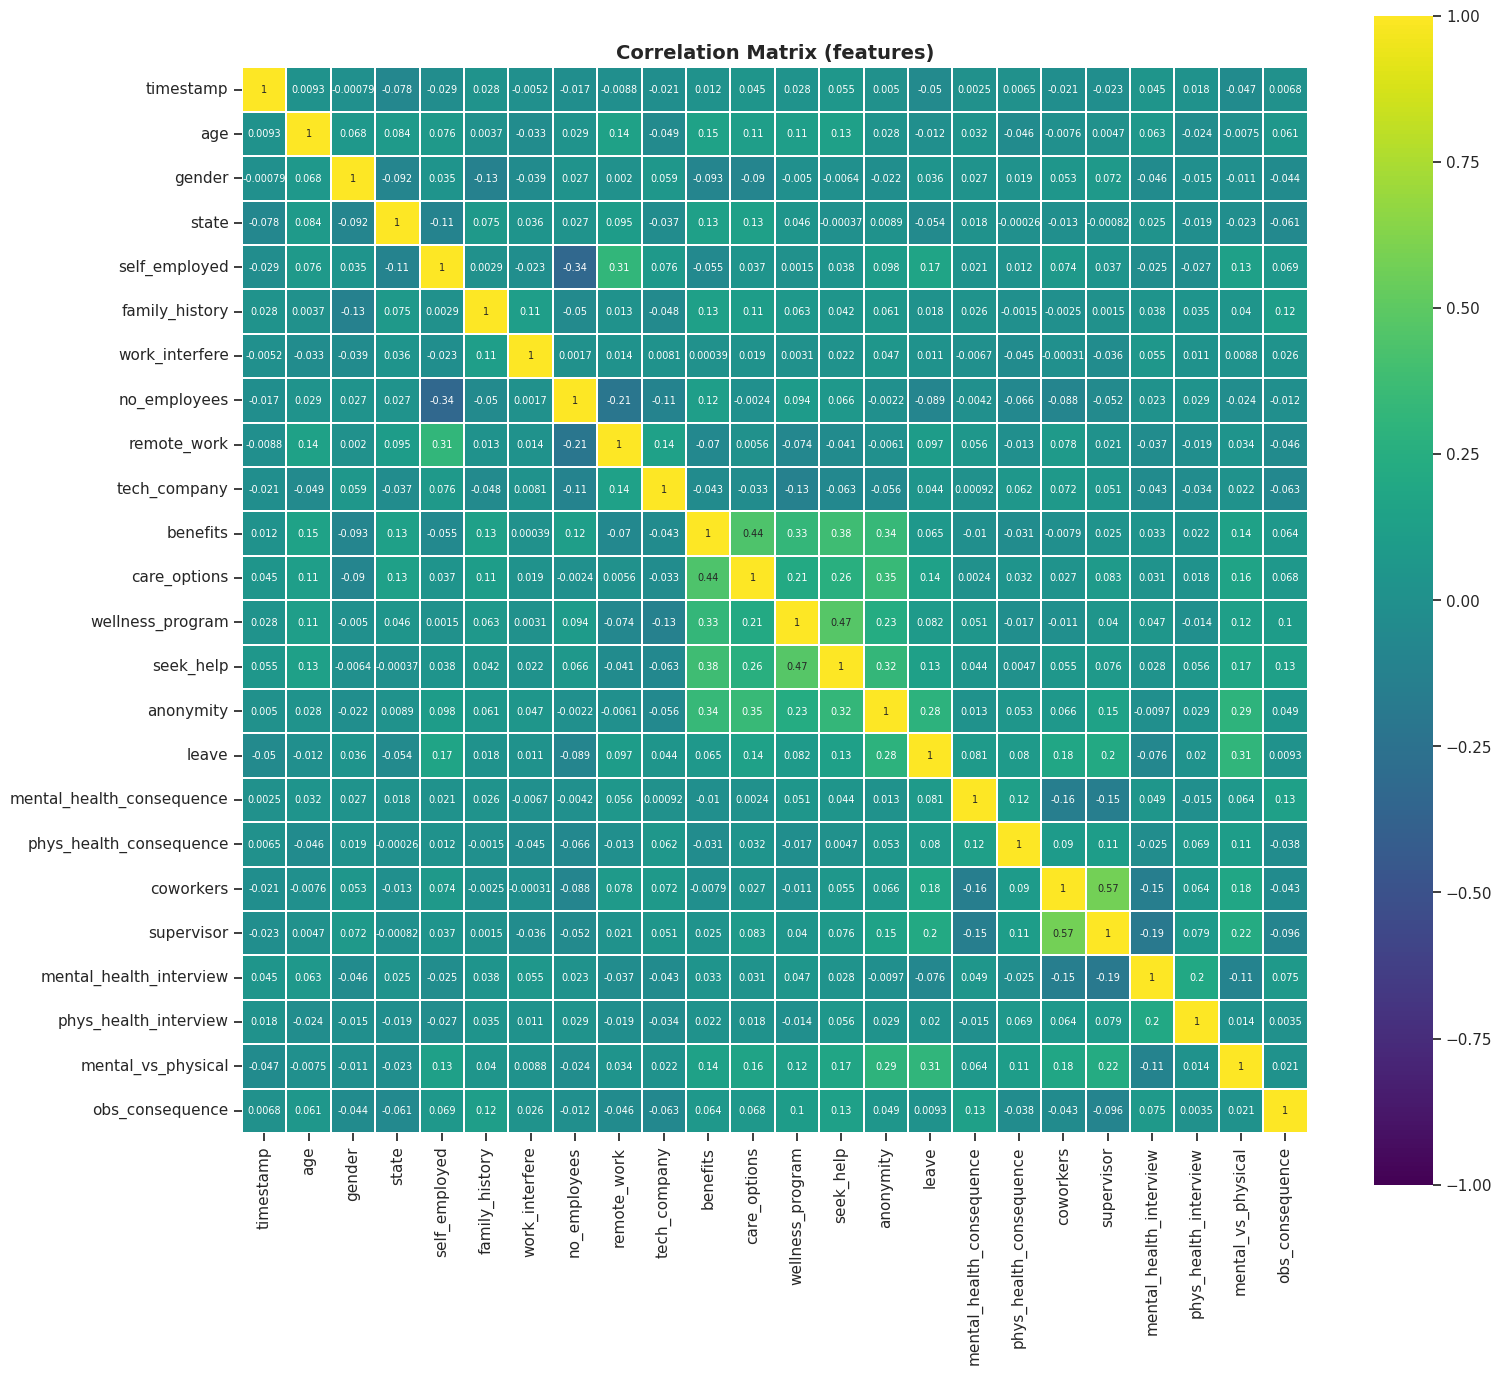

In [10]:
df_num = df_EDA.drop(columns=['Target']).select_dtypes(include='number')
corr = df_num.corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr,
    cmap='viridis',
    vmax=1.0, vmin=-1.0,
    linewidths=0.1,
    annot=True,
    annot_kws={'size': 7},
    square=True
)
plt.title('Correlation Matrix (features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Conclusions we can draw from the correlation map:

- `benefits` and `care_options` have a correlation of 0.44, making them one of the most correlated pairs in the entire dataset. This makes sense: companies that offer health benefits also tend to offer care options. It might be worth considering keeping only one of the two.


- `coworkers` and `supervisor` show a correlation of 0.57 — both measure openness to talk about mental health at work, which makes them somewhat redundant with each other; removing one of these variables could be considered.


- `wellness_program` and `seek_help` have a correlation of 0.47 — logical, since wellness programs are usually accompanied by resources for seeking help.

### 7.2 Feature Correlation with the Target (Spearman)

**What we do here:** Spearman correlation (which captures monotonic, not just linear, relationships) is used to rank every feature by how strongly it relates to `Target`. The top 10 are kept for the pairplot below and used as a sanity check against the model-driven feature importance in Section 17.

In [11]:
cor = df_EDA.corr(method='spearman', numeric_only=True)['Target'].abs().sort_values(ascending=False)
top_features = cor[1:11].index.tolist()  # [1:] skips Target's correlation with itself (always 1.0)

print('Top 10 features most correlated with Target:')
print(cor[1:11])


Top 10 features most correlated with Target:
family_history             0.376067
care_options               0.232769
benefits                   0.224420
gender                     0.157417
obs_consequence            0.151016
anonymity                  0.144256
mental_health_interview    0.094681
wellness_program           0.093025
seek_help                  0.086911
work_interfere             0.078096
Name: Target, dtype: float64


**🎯 Top correlated features with `Target` (Spearman):**

| Feature | Correlation |
|---|---|
| `family_history` | 0.376 |
| `care_options` | 0.233 |
| `benefits` | 0.224 |
| `gender` | 0.157 |
| `obs_consequence` | 0.151 |
| `anonymity` | 0.144 |
| `mental_health_interview` | 0.095 |
| `wellness_program` | 0.093 |
| `seek_help` | 0.087 |
| `work_interfere` | 0.078 |

`family_history` stands out as by far the strongest single predictor — more than 1.5× stronger than the next best feature. This matches clinical intuition: people with a family history of mental illness are both more likely to recognize symptoms in themselves and more likely to already be familiar with treatment. Company-level factors (`care_options`, `benefits`) come next, suggesting that workplace support genuinely correlates with treatment-seeking behavior, not just personal/family factors.

### 7.3 Pairplot by Class

**What we do here:** a scatterplot matrix of the top 10 correlated features, colored by `Target`, to visually check whether any pair of features cleanly separates the two classes (which a single correlation number can't show).

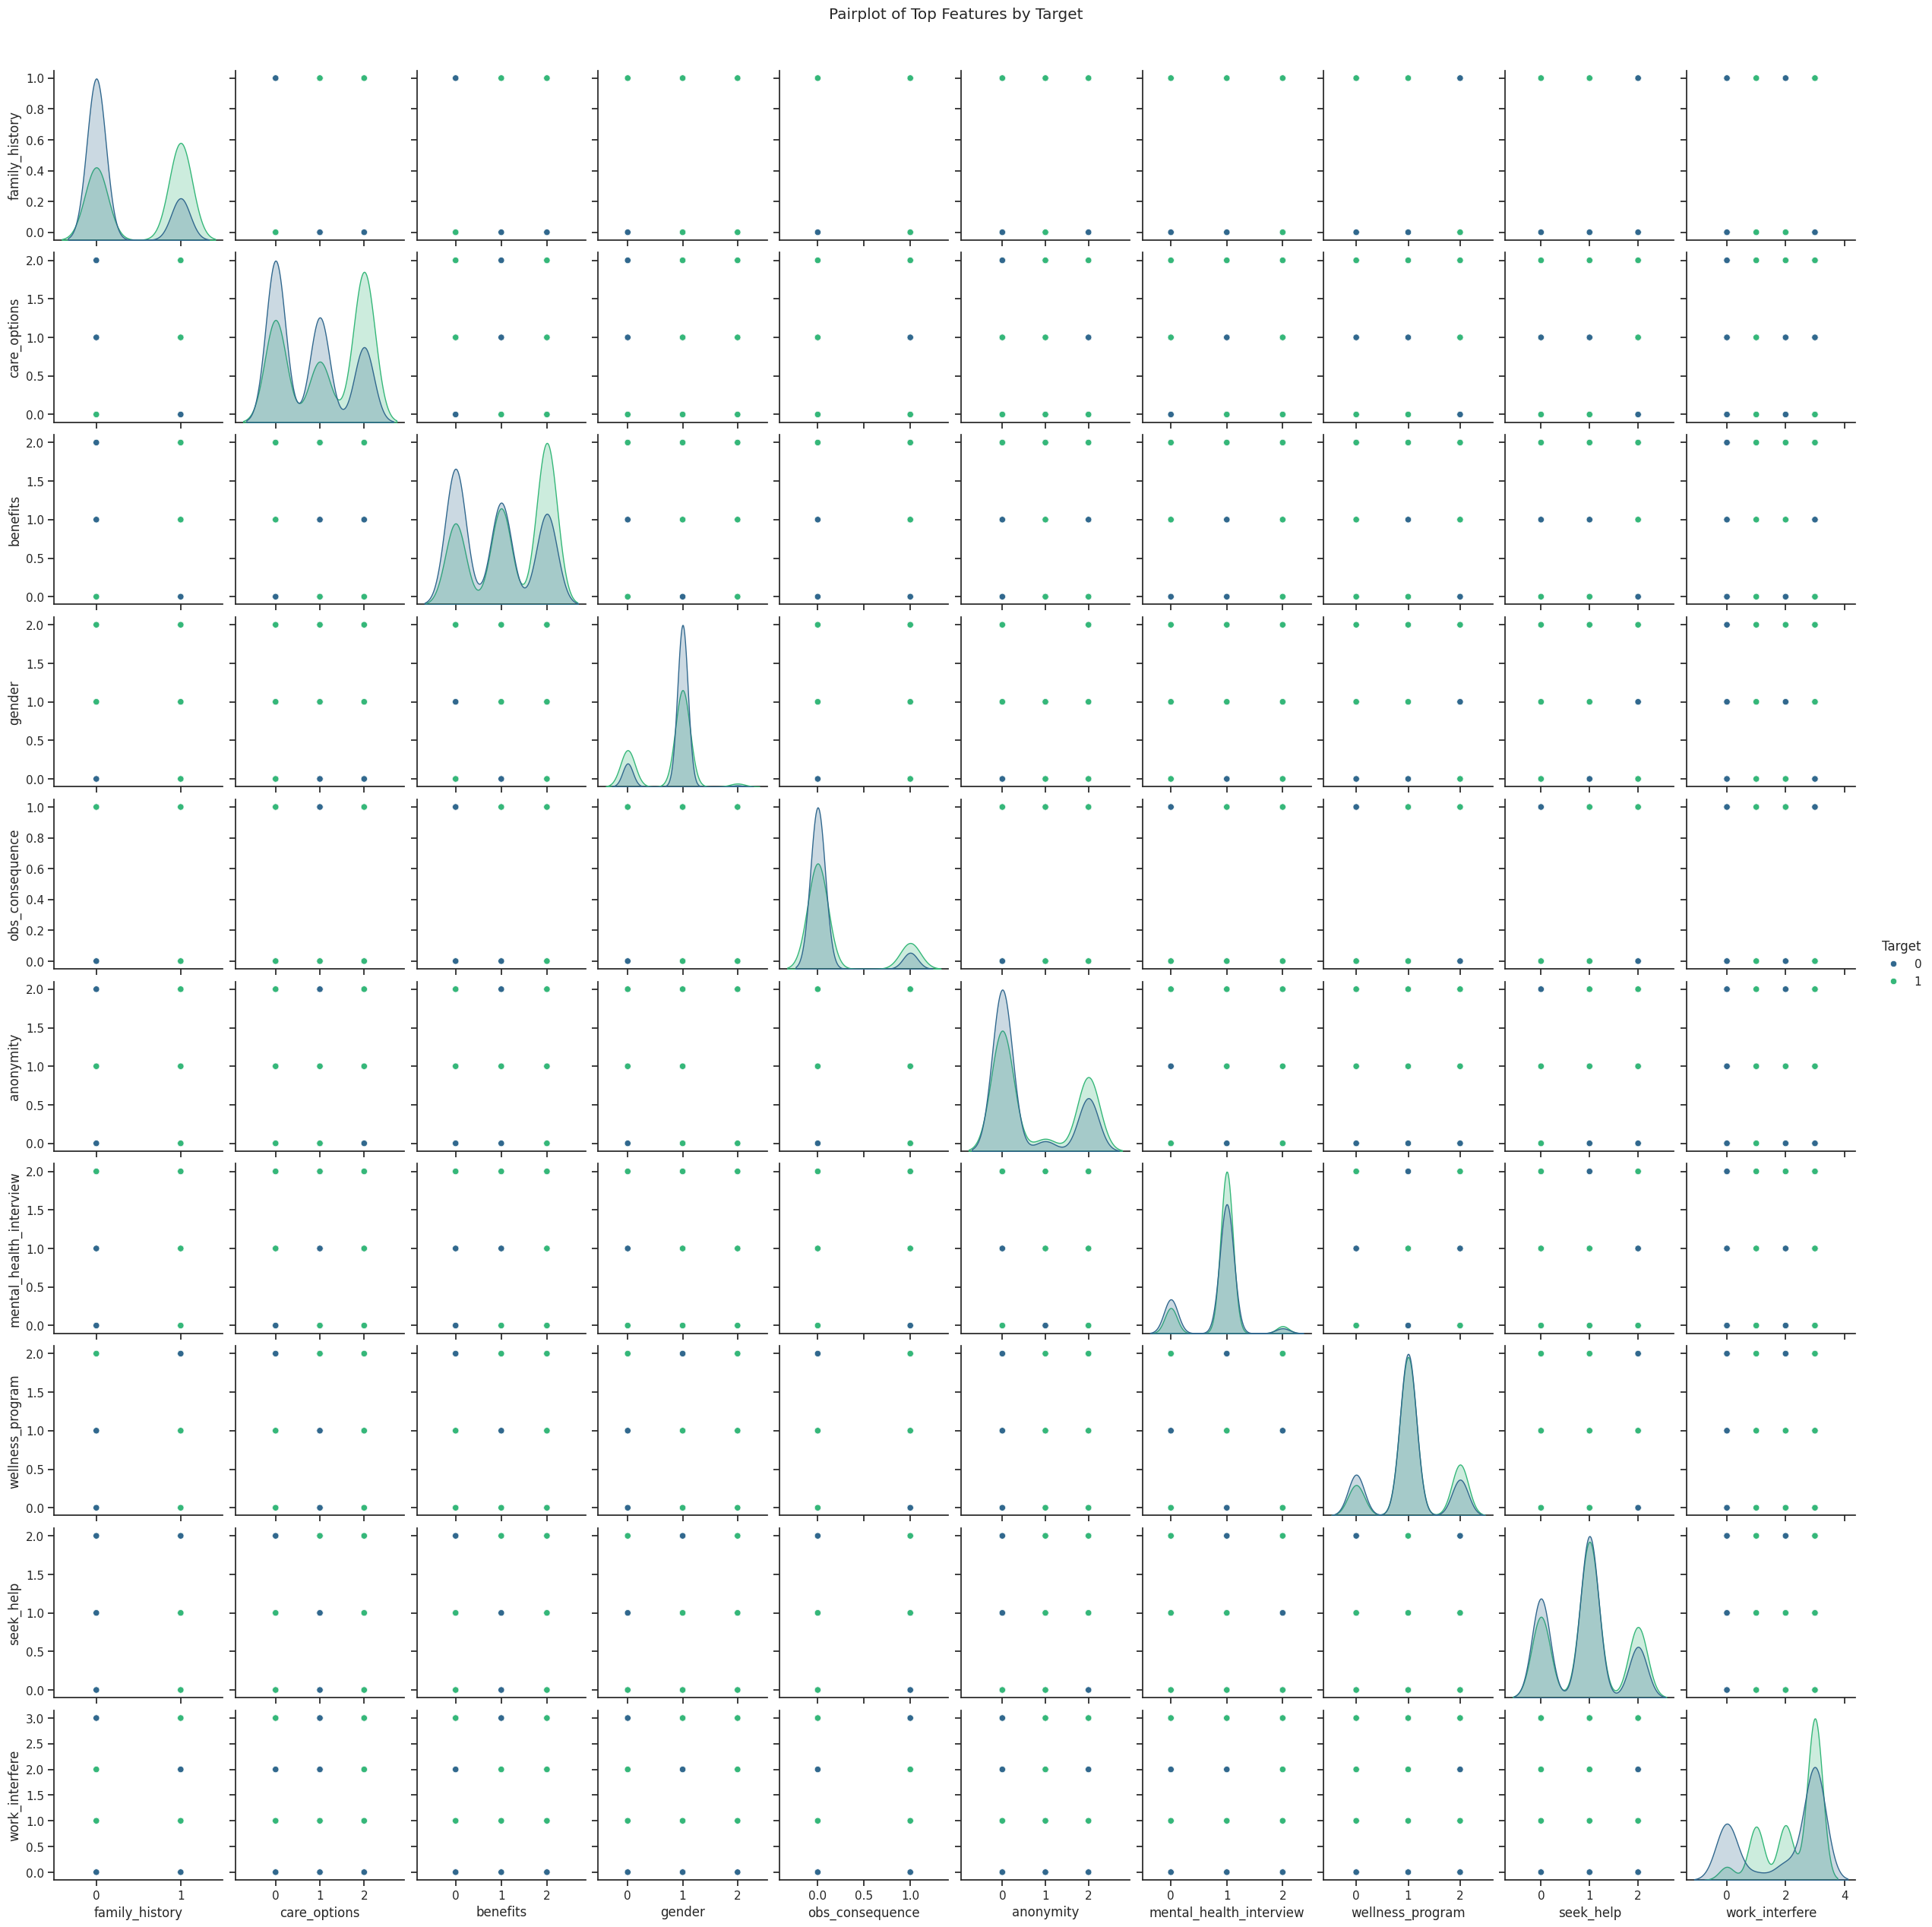

In [12]:
sns.pairplot(df_EDA[top_features + ['Target']], hue='Target', palette='viridis')
plt.suptitle('Pairplot of Top Features by Target', y=1.02)
plt.show()


### 7.4 Box Plots of Key Variables

**What we do here:** box plots make it easy to compare the distribution of a handful of hand-picked, domain-relevant variables across the two `Target` groups, side by side.

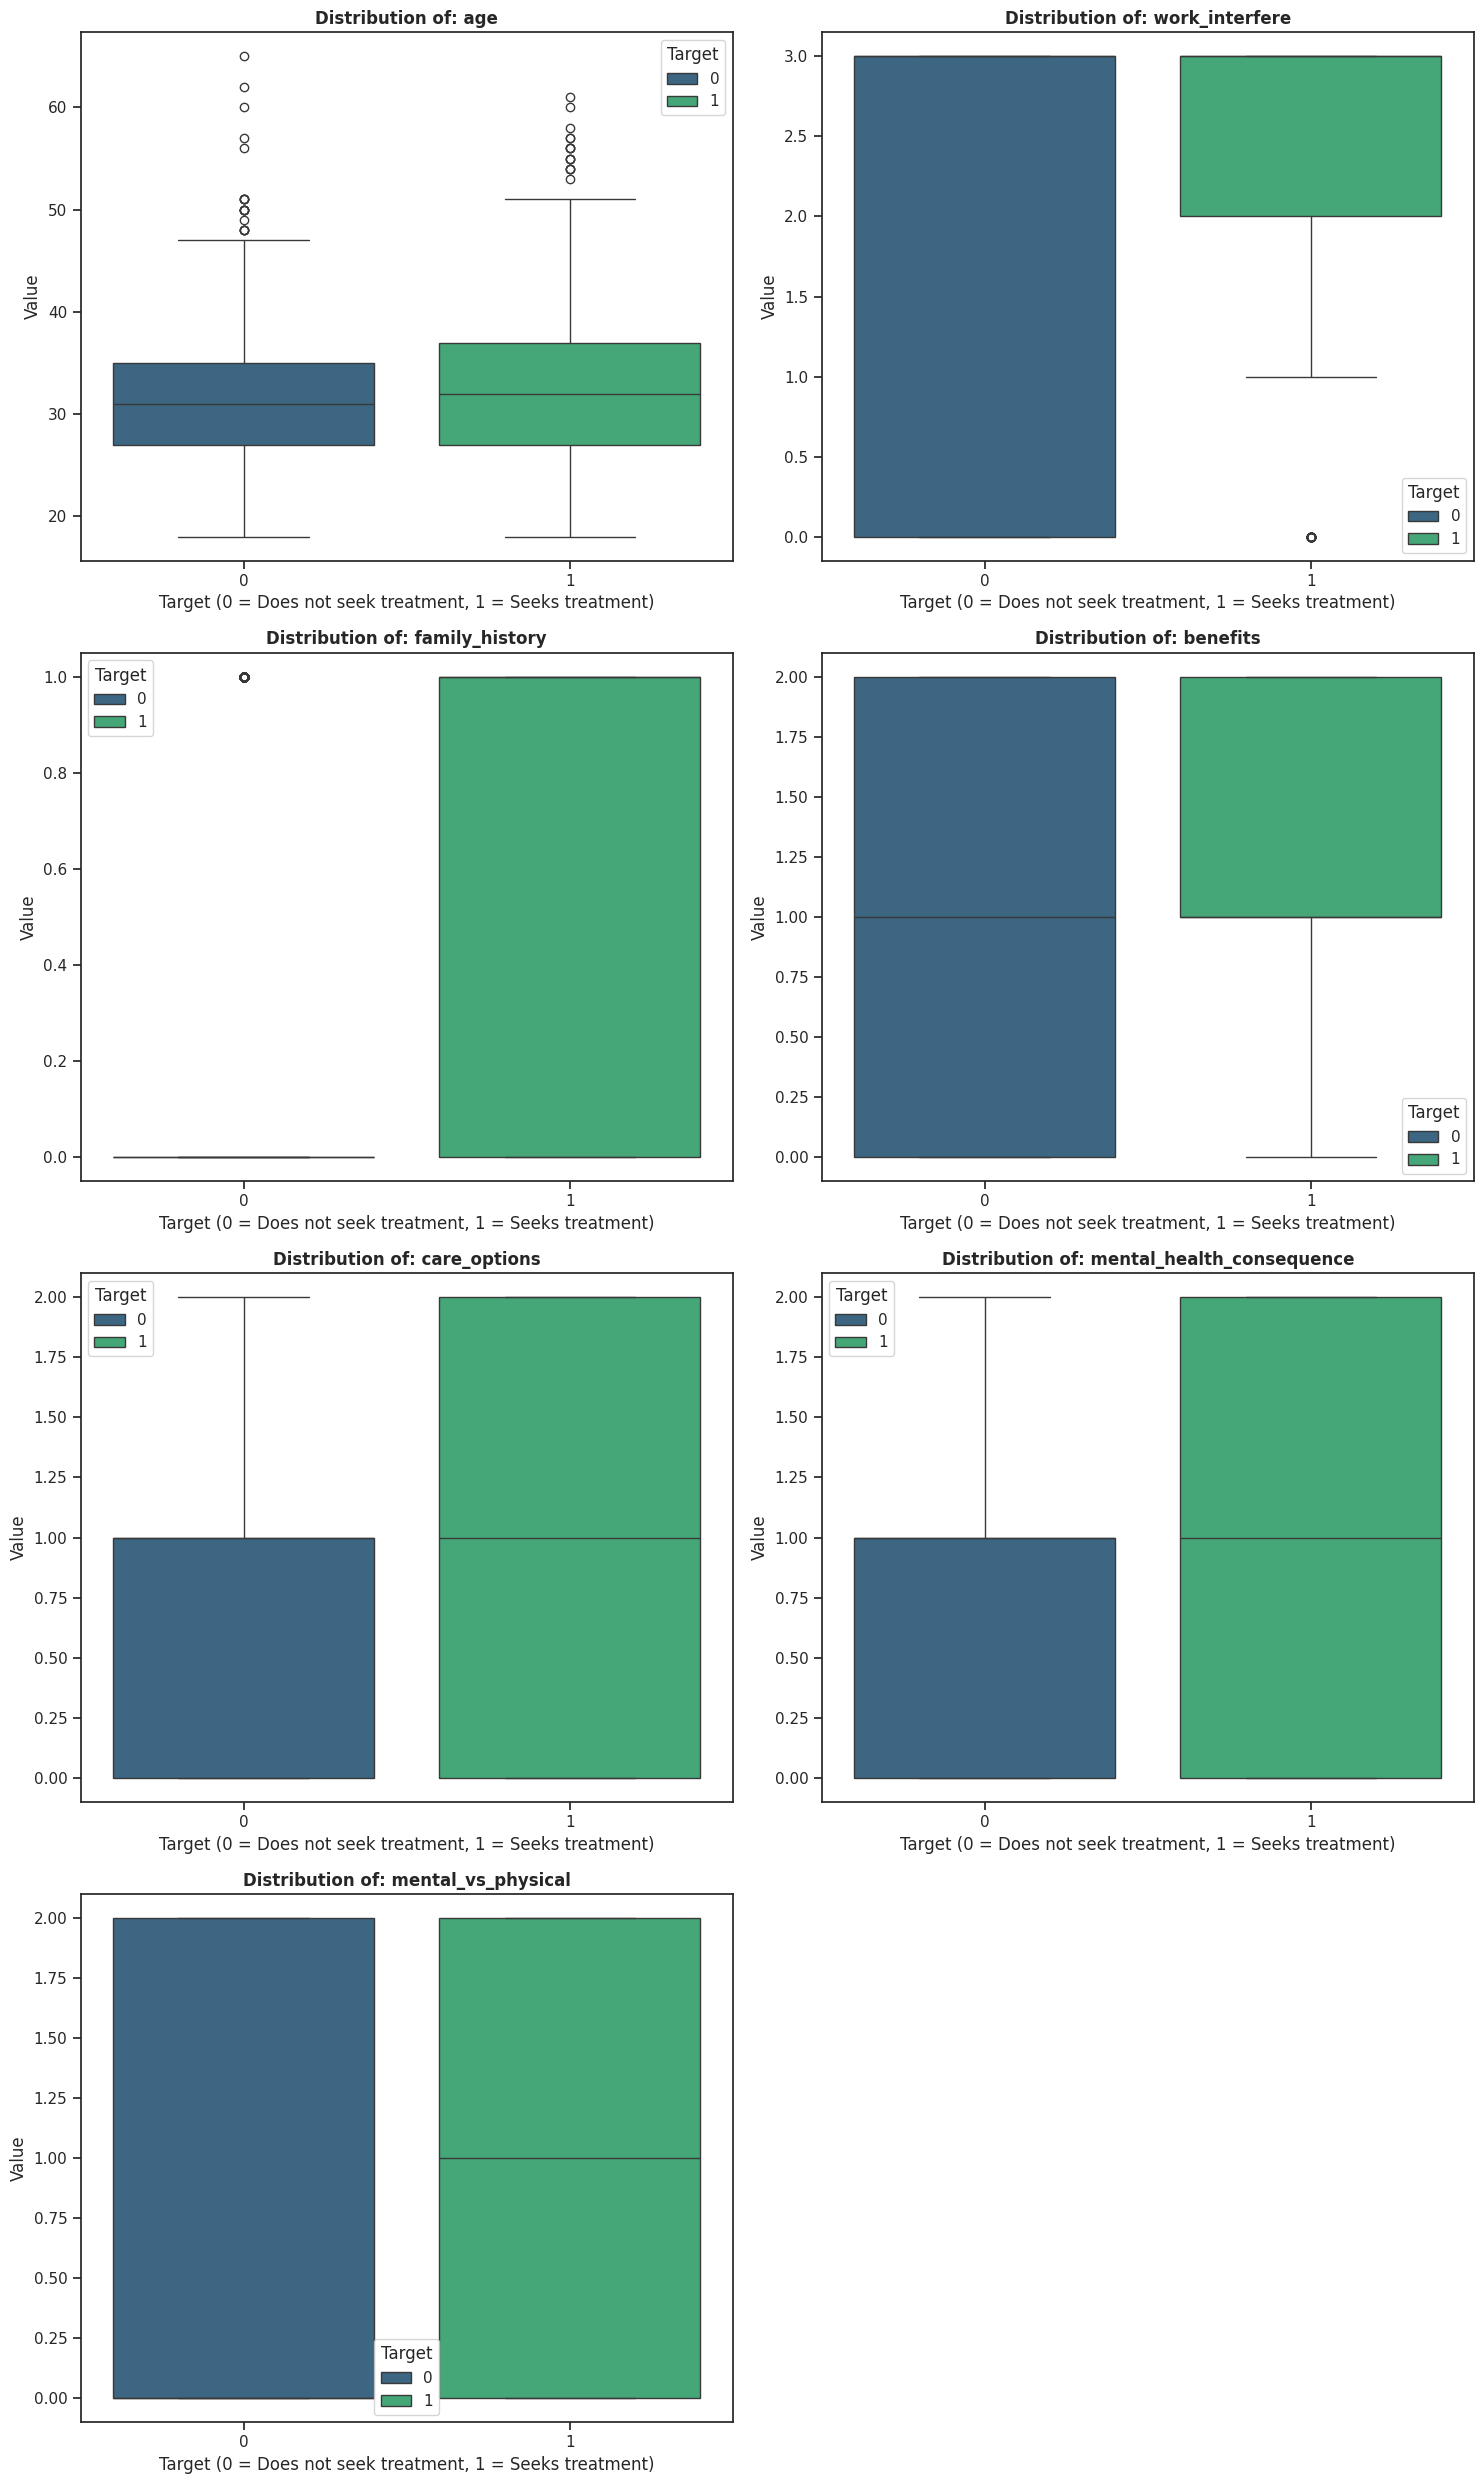

In [13]:
columnas_estudio = [
    'age', 'work_interfere', 'family_history',
    'benefits', 'care_options', 'mental_health_consequence', 'mental_vs_physical'
]

fig, axes = plt.subplots(4, 2, figsize=(15, 25))
axes = axes.flatten()

for i, col in enumerate(columnas_estudio):
    sns.boxplot(
        data=df_EDA,
        x='Target', y=col,
        hue='Target',
        palette='viridis',
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Target (0 = Does not seek treatment, 1 = Seeks treatment)')
    axes[i].set_ylabel('Value')

fig.delaxes(axes[7])  # remove the unused 8th subplot (only 7 variables are studied)
plt.tight_layout()
plt.show()


**📦 Box plot takeaways:** the clearest visual separation between the two `Target` groups shows up for `family_history` and `work_interfere` — consistent with their high correlation scores above. Variables like `mental_vs_physical` and `mental_health_consequence` show more overlapping distributions, suggesting they're weaker standalone predictors, but they may still add value in combination with others (which is exactly what the GridSearchCV-tuned models test starting in Section 11).

Not all of our categories contribute equally to predicting whether someone seeks treatment. This section aims to answer the question: which variables actually matter to the model? To do this, we will use 4 different methods, each with a different underlying logic, and then compare them.

> **Note:** the four methods below are described conceptually as a roadmap for deeper feature-selection work. The modeling pipeline in this notebook proceeds directly with all encoded features (excluding `country` and `comments`), relying on each model's own internal handling of feature relevance — and on the Gradient Boosting feature importances in Section 17 — rather than running this multi-method selection explicitly. Implementing it is listed as a next step in the final conclusions.

Chi-Square (statistical dependence), RFE (recursive feature elimination), Mutual Information (non-linear relationships), and SMLR (cross-validated coefficients)

## 9. Train/Test Split

**What we do here:** the data is split 80/20 into train and test sets. `stratify=y` is used to preserve the ~50/50 class balance in both sets — important so that neither set accidentally ends up skewed toward one class. Scaling is applied only to the continuous numerical variable (`age`); the encoded categorical columns are left as integer codes, since most of our models (especially the tree-based ones that win in the end) don't require scaled inputs.

In [14]:
X = df_EDA.drop(columns=['Target'])
y = df_EDA['Target']

print('Target distribution:')
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale only the continuous numerical variable; fit on train, transform both train and test
# (fitting only on train avoids leaking test-set information into the scaling parameters)
cols_numericas = ['age']
scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[cols_numericas] = scaler.fit_transform(X_train[cols_numericas])
X_test[cols_numericas]  = scaler.transform(X_test[cols_numericas])

print(f'\nTrain: {X_train.shape} | Test: {X_test.shape}')


Target distribution:
Target
1    631
0    619
Name: count, dtype: int64
Target
1    0.505
0    0.495
Name: proportion, dtype: float64

Train: (1000, 26) | Test: (250, 26)


**Split summary:** 1,000 records for training and 250 for testing, with the same ~50/50 class balance preserved in both sets thanks to `stratify=y`.

## 10. Models and Evaluation Functions

**What we do here:** we define 9 classifiers spanning several different algorithm families, so we can compare approaches rather than betting on a single one:

- **Tree-based:** Decision Tree (`DTC`), Random Forest (`RF`), Extra Trees (`ETC`), Gradient Boosting (`GB`)
- **Distance-based:** K-Nearest Neighbors (`KNN`)
- **Linear:** Logistic Regression (`LR`), SGD Classifier (`SGDC`)
- **Margin-based:** Support Vector Classifier (`SVC`)
- **Neural network:** Multi-Layer Perceptron (`MLP`)

We also define two helper functions used throughout the rest of the notebook: `evaluar_modelo()` computes accuracy/precision/recall/F1 for a model's predictions, and `graficar_confusion()` draws a labeled confusion matrix so results are easy to read at a glance.

In [15]:
models = {
    'DTC':  DecisionTreeClassifier(random_state=0),                                            # tree-based
    'RF':   RandomForestClassifier(random_state=0),                                             # tree-based (ensemble)
    'ETC':  ExtraTreesClassifier(random_state=0),                                                # tree-based (ensemble)
    'GB':   GradientBoostingClassifier(random_state=0),                                          # tree-based (boosted ensemble)
    'KNN':  KNeighborsClassifier(),                                                              # distance-based
    'SGDC': SGDClassifier(random_state=0),                                                       # linear
    'LR':   LogisticRegression(random_state=0, max_iter=5000, class_weight='balanced'),           # linear
    'MLP':  MLPClassifier(random_state=0, max_iter=500),                                          # neural network
    'SVC':  SVC(random_state=0, probability=True, class_weight='balanced')                        # margin-based
}

# 5-fold stratified CV is reused across every GridSearchCV run below, so all models are tuned
# and compared under exactly the same validation scheme
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def evaluar_modelo(nombre, y_true, y_pred):
    """Computes and returns the classification metrics for a model."""
    return {
        'Model':      nombre,
        'Accuracy':   accuracy_score(y_true, y_pred),
        'Precision':  precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall':     recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1 Score':   f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

def graficar_confusion(y_true, y_pred, titulo):
    """Plots the confusion matrix with descriptive labels."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['No Treatment', 'Seeks Treatment'],
        yticklabels=['No Treatment', 'Seeks Treatment']
    )
    plt.title(titulo, fontweight='bold')
    plt.xlabel('Prediction')
    plt.ylabel('Actual Value')
    plt.tight_layout()
    plt.show()


## 11. Hyperparameter Optimization with GridSearchCV

**What we do here:** instead of using each model's default settings, we search over a small grid of reasonable hyperparameter values for each one, using 5-fold cross-validation to pick the combination that maximizes the weighted F1-score. This avoids both underfitting (too-simple defaults) and overfitting (picking parameters based on the test set, which we never touch during this search).

Stratified cross-validation (5-fold) is used to search for the best hyperparameters for each model, optimizing the F1-score. This approach was chosen based on the following number of training combinations:

DTC: 4 × 2 × 2 × 1 = 16

RF: 2 × 3 × 2 × 2 × 1 × 1 = 24

ETC: 2 × 2 × 2 × 1 × 1 = 8

GB: 2 × 2 × 2 = 8

KNN: 3 × 1 × 1 = 3

SGDC: 1 × 1 × 2 = 2

LR: 3 × 1 × 1 = 3

MLP: 2 × 1 × 1 × 2 × 1 = 4

for a total of 68 combinations.
In addition, we also use StratifiedKFold with 5 folds, which implicitly multiplies these 68 combinations, giving a total of 340 trainings overall.

In [16]:
param_grids = {
    'DTC':  {'max_depth': [8, 12, 16, None], 'min_samples_split': [5, 10],
             'min_samples_leaf': [2, 4], 'criterion': ['gini']},
    'RF':   {'n_estimators': [200, 400], 'max_depth': [12, 18, None],
             'min_samples_split': [5, 10], 'min_samples_leaf': [2, 4],
             'max_features': ['sqrt'], 'class_weight': ['balanced']},
    'ETC':  {'n_estimators': [200, 400], 'max_depth': [12, None],
             'min_samples_leaf': [2, 4], 'criterion': ['gini'],
             'class_weight': ['balanced']},
    'GB':   {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 4]},
    'KNN':  {'n_neighbors': [7, 9, 11], 'weights': ['distance'], 'metric': ['manhattan']},
    'SGDC': {'loss': ['log_loss'], 'penalty': ['l2'], 'alpha': [0.001, 0.01]},
    'LR':   {'C': [0.1, 1, 10], 'solver': ['liblinear'], 'class_weight': ['balanced']},
    'MLP':  {'hidden_layer_sizes': [(50,), (100,)], 'activation': ['relu'],
             'solver': ['adam'], 'alpha': [0.0001, 0.001], 'learning_rate': ['adaptive']},
    'SVC': {'C': [1, 10], 'kernel': ['rbf'], 'gamma': ['scale']}
}

best_models = {}
print('Starting hyperparameter search... this may take a few minutes.\n')

# GridSearchCV requires purely numeric input, so any leftover non-numeric columns
# ('country', 'comments') are dropped here before fitting
non_numeric_cols = X_train.select_dtypes(include='object').columns.tolist()
if non_numeric_cols:
    print(f"Removing non-numeric columns from X_train and X_test for the GridSearch: {non_numeric_cols}\n")
    X_train_numeric = X_train.drop(columns=non_numeric_cols)
    X_test_numeric = X_test.drop(columns=non_numeric_cols)
else:
    X_train_numeric = X_train
    X_test_numeric = X_test

for name, model in models.items():
    print(f'Optimizing {name}...')
    gs = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=cv_strategy,
        # Track both F1 and accuracy during the search, but select the best combination by F1
        # (more informative than accuracy alone, even though the target is fairly balanced)
        scoring={
    'f1':       make_scorer(f1_score, average='weighted', zero_division=0),
    'accuracy': make_scorer(accuracy_score)
},
refit='f1',
    )
    gs.fit(X_train_numeric, y_train)
    best_models[name] = gs.best_estimator_
    print(f'  Best parameters: {gs.best_params_}')
    print(f'  Best F1 (CV):      {gs.best_score_:.4f}')

    # Retrieve the best accuracy score from cv_results (corresponding to the same best_index_ as F1)
    best_idx = gs.best_index_
    best_accuracy_score = gs.cv_results_['mean_test_accuracy'][best_idx]
    print(f'  Best Accuracy (CV): {best_accuracy_score:.4f}\n')

print('Search complete!')


Starting hyperparameter search... this may take a few minutes.

Removing non-numeric columns from X_train and X_test for the GridSearch: ['country', 'comments']

Optimizing DTC...
  Best parameters: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 10}
  Best F1 (CV):      0.6871
  Best Accuracy (CV): 0.6880

Optimizing RF...
  Best parameters: {'class_weight': 'balanced', 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
  Best F1 (CV):      0.7399
  Best Accuracy (CV): 0.7400

Optimizing ETC...
  Best parameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 400}
  Best F1 (CV):      0.7359
  Best Accuracy (CV): 0.7360

Optimizing GB...
  Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
  Best F1 (CV):      0.7369
  Best Accuracy (CV): 0.7370

Optimizing KNN...
  Best parameters: {'metric': 'manhattan', 

**🔬 Cross-validation results (best F1 per model):**

| Model | Best F1 (CV) | Best Accuracy (CV) |
|---|---|---|
| Random Forest | 0.740 | 0.740 |
| Gradient Boosting | 0.737 | 0.737 |
| Extra Trees | 0.736 | 0.736 |
| Decision Tree | 0.687 | 0.688 |
| KNN | 0.529 | 0.530 |
| Logistic Regression | 0.339 | 0.505 |
| MLP | 0.335 | 0.501 |
| SGD Classifier | 0.330 | 0.497 |
| SVC | 0.328 | 0.495 |

⚠️ **Important pattern:** the four tree-based models clearly outperform everything else, while KNN, MLP, Logistic Regression, SGD, and SVC barely beat random guessing (≈50% accuracy on this balanced target) — and their F1 scores (~0.33) are even worse than their accuracy, a strong sign they're predicting mostly one class. The likely cause: `LabelEncoder` assigns arbitrary numeric codes to categorical values with no real order (see the warning in Section 6). Tree-based models don't care about this — they just split on thresholds — but linear/distance/margin-based models treat those codes as if they were meaningful numeric distances, which actively misleads them. We revisit this with hard numbers in Section 15, once we see how PCA affects each group differently.

## 12. Evaluation of Optimized Models (Without PCA)

**What we do here:** every tuned model is finally evaluated on the held-out test set (data it has never seen, not even during cross-validation), giving us an honest estimate of real-world performance.

Results on Test Set (Without PCA):


,Accuracy,Precision,Recall,F1 Score
GB,0.772,0.772032,0.772,0.772004
ETC,0.760,0.760328,0.760,0.759969
RF,0.752,0.752322,0.752,0.751968
DTC,0.708,0.711317,0.708,0.707086
KNN,0.532,0.532108,0.532,0.531978
SGDC,0.504,0.254016,0.504,0.337787
LR,0.504,0.254016,0.504,0.337787
MLP,0.496,0.246016,0.496,0.328898
SVC,0.496,0.246016,0.496,0.328898



Best model: GB
              precision    recall  f1-score   support

           0       0.77      0.77      0.77       124
           1       0.78      0.77      0.77       126

    accuracy                           0.77       250
   macro avg       0.77      0.77      0.77       250
weighted avg       0.77      0.77      0.77       250



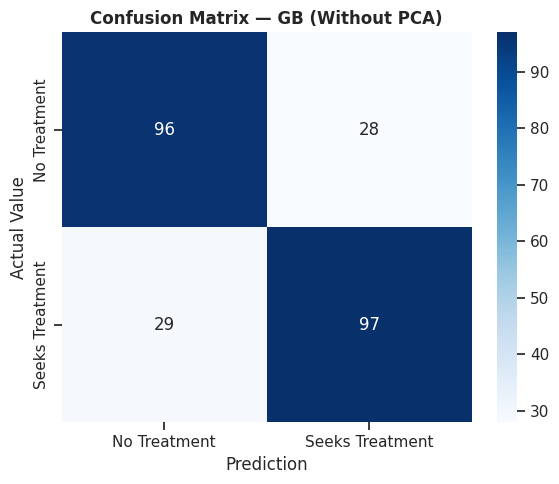

In [17]:
results_test = {}

for name, model in best_models.items():
    y_pred = model.predict(X_test_numeric)
    results_test[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall':    recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1 Score':  f1_score(y_test, y_pred, average='weighted', zero_division=0),
    }

df_results_test = pd.DataFrame.from_dict(results_test, orient='index')
print('Results on Test Set (Without PCA):')
display(df_results_test.sort_values('F1 Score', ascending=False))

# Identify and report on the single best model from this comparison
best_name_no_pca = df_results_test['F1 Score'].idxmax()
y_pred_best = best_models[best_name_no_pca].predict(X_test_numeric)
print(f'\nBest model: {best_name_no_pca}')
print(classification_report(y_test, y_pred_best, zero_division=0))
graficar_confusion(y_test, y_pred_best, f'Confusion Matrix — {best_name_no_pca} (Without PCA)')


**📊 Test-set results (no PCA):** Gradient Boosting comes out on top with **77.2% accuracy / F1**, closely followed by Extra Trees (76.0%) and Random Forest (75.2%) — consistent with the cross-validation ranking above. The weak performers (SVC, LR, SGDC, MLP) confirm the pattern seen during tuning: F1 scores around 0.33 despite ~50% accuracy mean these models are essentially defaulting to one class most of the time.

## 13. Dimensionality Reduction with PCA

**What we do here:** as an alternative pipeline, PCA is applied to the (re-)scaled feature set, keeping enough components to preserve 96% of the explained variance. This lets us test whether compressing/decorrelating the feature space helps any of the 9 models.

In [18]:
scaler_pca = StandardScaler()
X_train_sc = scaler_pca.fit_transform(X_train_numeric)
X_test_sc  = scaler_pca.transform(X_test_numeric)

pca = PCA(n_components=0.96)  # keep enough components to explain 96% of the variance
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

print(f'Original variables:  {X_train_sc.shape[1]}')
print(f'Components after PCA:  {X_train_pca.shape[1]}')
print(f'Explained variance:    {sum(pca.explained_variance_ratio_):.4f}')


Original variables:  24
Components after PCA:  22
Explained variance:    0.9626


**📉 PCA summary:** going from 24 numeric features down to 22 components still preserves 96.3% of the variance — in other words, PCA barely compresses anything here. This already hints that the original features don't carry much redundant information (consistent with the fairly low correlations seen in the heatmap, aside from a few pairs). With so little actual compression, any change in model performance after PCA is more likely coming from the *rescaling and decorrelation* PCA performs internally, not from genuine dimensionality reduction — a hint we confirm with numbers in Section 15.

## 14. Evaluation of Optimized Models (With PCA)

**What we do here:** the same 9 already-tuned models are retrained on the PCA-transformed features and evaluated on the (also PCA-transformed) test set, so we can compare them head-to-head against their no-PCA counterparts in the next section.

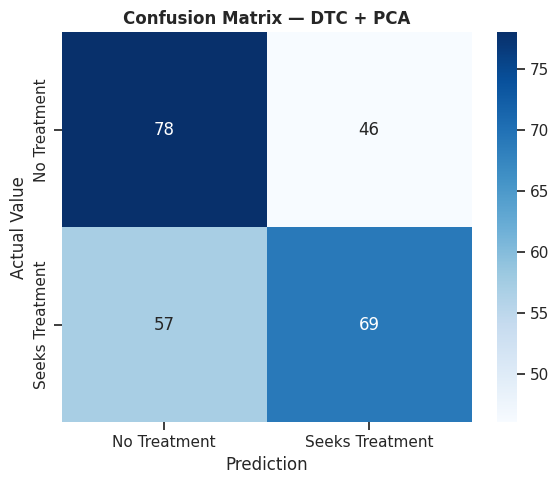

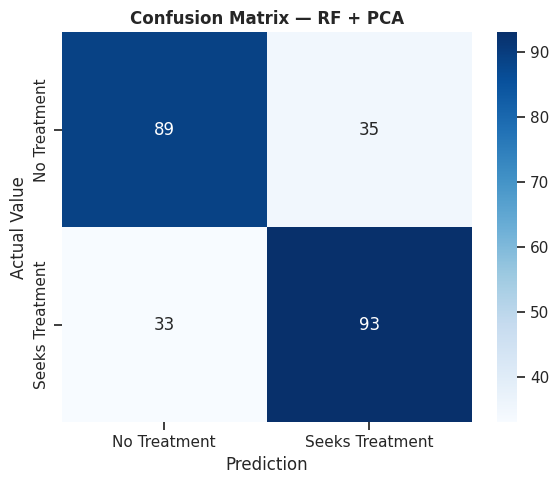

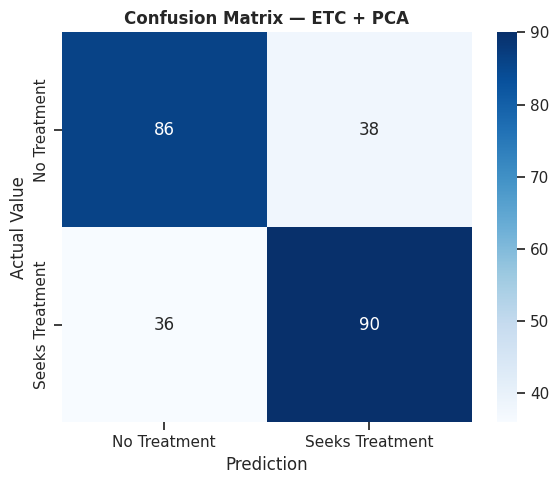

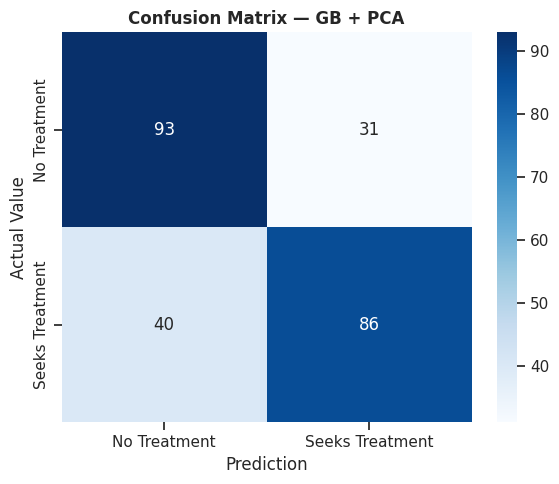

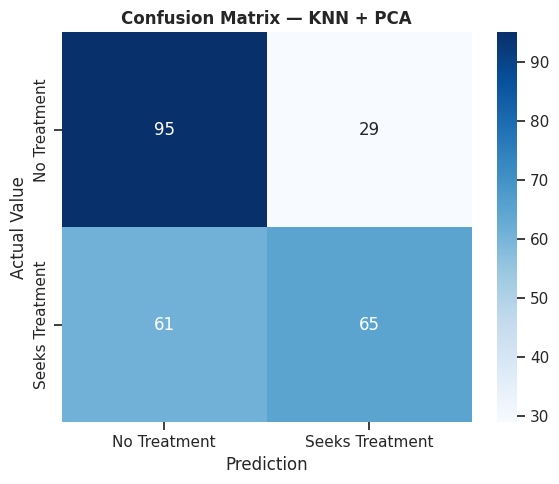

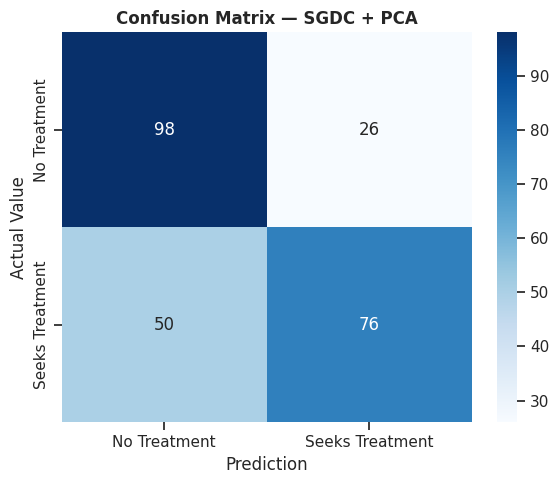

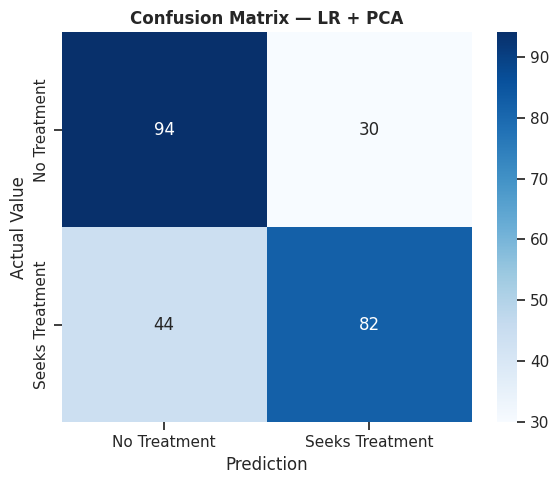

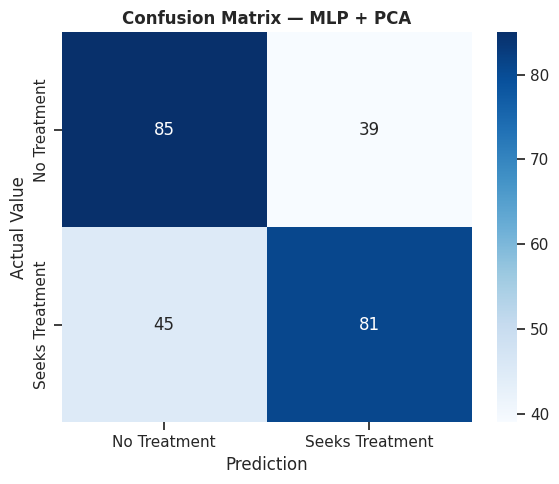

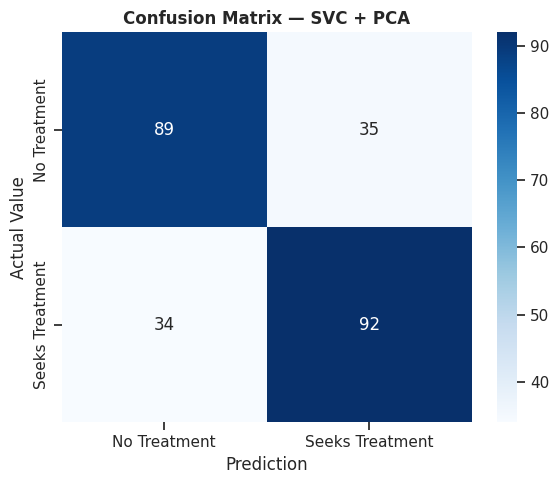

Results on Test Set (With PCA):


,Accuracy,Precision,Recall,F1 Score
Model,,,,
RF + PCA,0.728,0.728024,0.728,0.727965
SVC + PCA,0.724,0.723997,0.724,0.723987
GB + PCA,0.716,0.717289,0.716,0.715714
ETC + PCA,0.704,0.704014,0.704,0.703962
LR + PCA,0.704,0.706855,0.704,0.703203
SGDC + PCA,0.696,0.703962,0.696,0.693412
MLP + PCA,0.664,0.664508,0.664,0.663871
KNN + PCA,0.640,0.650562,0.640,0.634390
DTC + PCA,0.588,0.588978,0.588,0.587347


In [19]:
resultados_con_pca = []

for nombre, modelo in best_models.items():
    modelo.fit(X_train_pca, y_train)
    y_pred = modelo.predict(X_test_pca)
    resultados_con_pca.append(evaluar_modelo(f'{nombre} + PCA', y_test, y_pred))
    graficar_confusion(y_test, y_pred, f'Confusion Matrix — {nombre} + PCA')

df_con_pca = pd.DataFrame(resultados_con_pca).set_index('Model')
print('Results on Test Set (With PCA):')
display(df_con_pca.sort_values('F1 Score', ascending=False))


## 15. Comparison: Without PCA vs. With PCA

**What we do here:** the F1-scores of each model are compared across both configurations to determine, model by model, whether PCA helps or hurts — and to understand why.

In [20]:
df_sinpca = df_results_test[['F1 Score']].rename(columns={'F1 Score': 'F1_NoPCA'})
df_conpca = df_con_pca[['F1 Score']].rename(columns={'F1 Score': 'F1_WithPCA'})
df_conpca.index = df_conpca.index.str.replace(' + PCA', '', regex=False)

comparison = df_sinpca.join(df_conpca, how='inner')
comparison['Diff_F1'] = comparison['F1_WithPCA'] - comparison['F1_NoPCA']
comparison = comparison.sort_values('Diff_F1', ascending=False)

print('F1 Comparison Without PCA vs With PCA:')
display(comparison)


F1 Comparison Without PCA vs With PCA:


,F1_NoPCA,F1_WithPCA,Diff_F1
SVC,0.328898,0.723987,0.395088
LR,0.337787,0.703203,0.365415
SGDC,0.337787,0.693412,0.355625
MLP,0.328898,0.663871,0.334973
KNN,0.531978,0.634390,0.102412
RF,0.751968,0.727965,-0.024003
ETC,0.759969,0.703962,-0.056007
GB,0.772004,0.715714,-0.056290
DTC,0.707086,0.587347,-0.119740


**🔑 Key finding — PCA helps some models and hurts others, and now we know why:**

| Model | F1 (No PCA) | F1 (With PCA) | Difference |
|---|---|---|---|
| SVC | 0.329 | 0.724 | **+0.395** |
| Logistic Regression | 0.338 | 0.703 | **+0.365** |
| SGD Classifier | 0.338 | 0.693 | **+0.356** |
| MLP | 0.329 | 0.664 | **+0.335** |
| KNN | 0.532 | 0.634 | **+0.102** |
| Random Forest | 0.752 | 0.728 | −0.024 |
| Extra Trees | 0.760 | 0.704 | −0.056 |
| Gradient Boosting | 0.772 | 0.716 | −0.056 |
| Decision Tree | 0.707 | 0.587 | −0.120 |

The split is almost perfectly clean: **every linear/distance/margin-based model improves dramatically with PCA** (SVC alone gains +0.40 F1), while **every tree-based model gets slightly worse**. This confirms the hypothesis from Section 11: PCA's internal `StandardScaler` step removes the artificial scale/ordering that `LabelEncoder` imposed on nominal categories — exactly what was confusing SVC, LR, SGDC, and MLP. Tree-based models never needed that fix; they were already splitting on raw category codes just fine, so for them PCA only throws away a small amount of genuinely useful information, which slightly hurts performance.

**Takeaway for future iterations:** instead of relying on PCA as a workaround, switching from `LabelEncoder` to **one-hot encoding** for nominal (non-ordinal) categorical variables would likely let linear/distance models perform well *without* needing PCA at all — worth testing as a follow-up experiment (see the final conclusions).

## 16. Selecting the Overall Best Model

**What we do here:** the best model without PCA is compared against the best model with PCA, and the single overall winner — the one we'll explain and validate in the remaining sections — is declared.

In [21]:
f1_no_pca  = df_results_test['F1 Score'].max()
name_no_pca = df_results_test['F1 Score'].idxmax()

f1_pca  = df_con_pca['F1 Score'].max()
name_pca = df_con_pca['F1 Score'].idxmax()

print(f'Best without PCA : {name_no_pca}  →  F1 = {f1_no_pca:.4f}')
print(f'Best with PCA : {name_pca}  →  F1 = {f1_pca:.4f}')

if f1_no_pca >= f1_pca:
    print(f'\n Winning model: {name_no_pca} (Without PCA) with F1 = {f1_no_pca:.4f}')
    final_model_name = name_no_pca
    final_model = best_models[name_no_pca]
    X_test_final = X_test
else:
    print(f'\n Winning model: {name_pca} with F1 = {f1_pca:.4f}')
    final_model_name = name_pca.replace(' + PCA', '')
    final_model = best_models[final_model_name]
    final_model.fit(X_train_pca, y_train)
    X_test_final = X_test_pca


Best without PCA : GB  →  F1 = 0.7720
Best with PCA : RF + PCA  →  F1 = 0.7280

 Winning model: GB (Without PCA) with F1 = 0.7720


**🏆 Final winner: Gradient Boosting (no PCA)**, with F1 = 0.772 — the best score of any model/pipeline combination tested in this notebook.

## 17. Feature Importance

**What we do here:** the winning model — Gradient Boosting, trained on the original (non-PCA) data — exposes a `feature_importances_` attribute that tells us how much each input feature contributed to its decisions. This is the most direct way to answer "what actually matters for this prediction?".

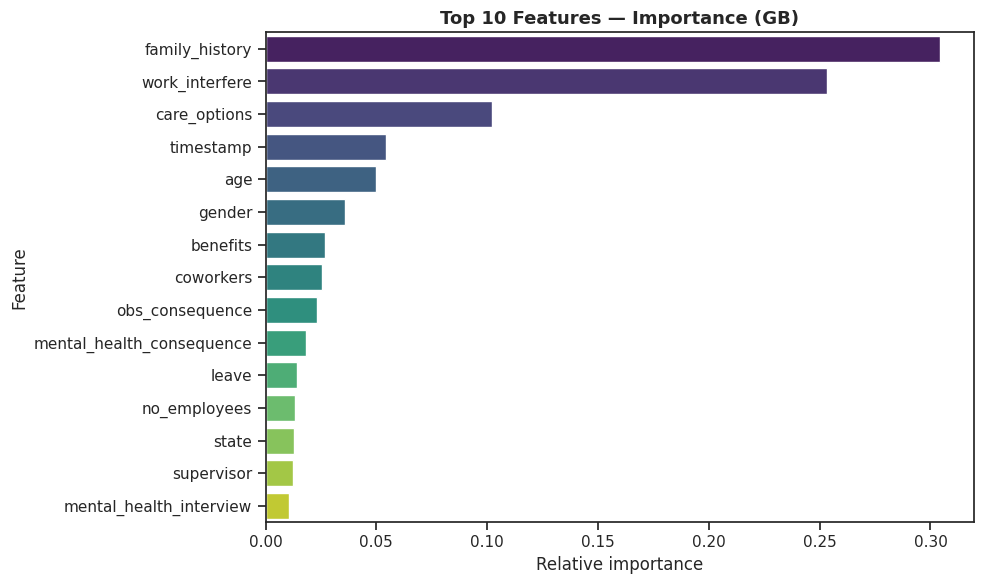

In [22]:
gb_best = best_models['GB']
gb_best.fit(X_train_numeric, y_train)

feature_importance_df = pd.DataFrame({
    'Feature':    X_train_numeric.columns,
    'Importance': gb_best.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 10 Features — Importance (GB)', fontsize=13, fontweight='bold')
plt.xlabel('Relative importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


**🧠 What actually drives the prediction?** According to Gradient Boosting's feature importances, three variables dominate:
1. **`family_history`** (~30% of total importance) — by far the single most influential feature, confirming the correlation analysis from Section 7.2.
2. **`work_interfere`** (~25%) — whether mental health already interferes with work is a strong signal that someone is more likely to seek treatment.
3. **`care_options`** (~10%) — awareness of employer-provided care options.

Together these three account for roughly two-thirds of the model's decision-making, while the remaining ~20 features each contribute a small amount. This is a useful, actionable insight for employers: **visible mental-health care options at work and reducing work interference are two of the few company-controllable levers that meaningfully relate to treatment-seeking.**

## 18. ROC Curve of the Final Model

**What we do here:** the ROC curve is generated for the final model, using the corresponding test data. It visualizes how well the model distinguishes between the two classes (seeks treatment vs. does not seek treatment) across every possible decision threshold — that is, the model's effectiveness independent of any single accuracy cutoff.

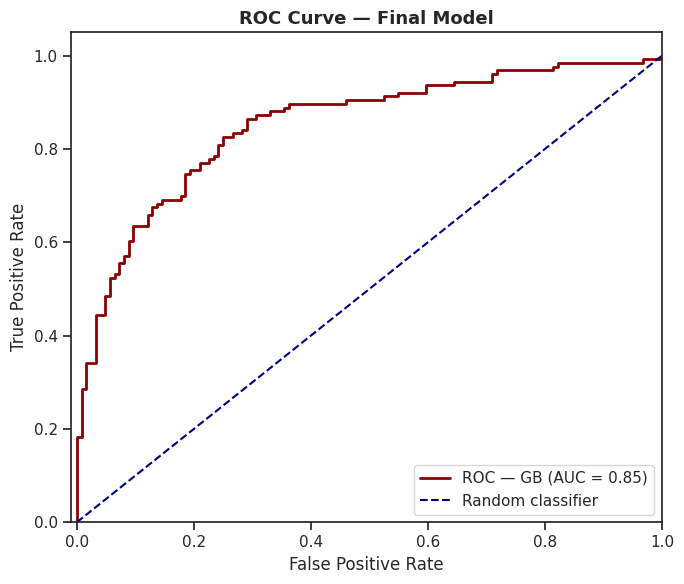

Final model AUC (GB): 0.8514


In [23]:
y_score = final_model.predict_proba(X_test_final.drop(columns=['country', 'comments']))[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkred', lw=2, label=f'ROC — {final_model_name} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random classifier')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Final Model', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'Final model AUC ({final_model_name}): {roc_auc:.4f}')


## 📌 Final Conclusions & Next Steps

**Summary of results:**
- **Best model:** Gradient Boosting, no PCA — Accuracy = F1 = 0.772, ROC AUC = 0.851.
- **Most predictive features:** `family_history`, `work_interfere`, `care_options` — personal history matters most, but workplace factors are a close second.
- **PCA insight:** PCA only helps models that are sensitive to feature scale/ordering (SVC, LR, SGDC, MLP, KNN); it slightly hurts tree-based models, which didn't need the fix in the first place. The root cause is `LabelEncoder` imposing artificial numeric order on nominal categories.

**Limitations:**
- The dataset is heavily skewed toward male respondents (986 of 1,250), so conclusions about gender effects should be treated cautiously.
- `country` and detailed free-text `comments` were excluded from modeling entirely — there may be useful signal left on the table (e.g. country-level mental-health policy differences).
- This is self-reported survey data from 2014; attitudes and company policies around mental health have likely shifted since then.

**Ideas to explore next:**
- Replace `LabelEncoder` with **one-hot encoding** for nominal variables and re-test the linear/distance models without PCA.
- Report metrics with full **k-fold cross-validation** (not just a single train/test split) for more robust final numbers.
- Run the **Chi-Square / RFE / Mutual Information / SMLR** feature-selection methods mentioned conceptually in Section 8, and compare the resulting feature subset against the full feature set used here.
- Bring `country` back in as a grouped/regional feature instead of dropping it entirely.